In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/jesucastin/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def hanging_line(point1, point2):
    import numpy as np

    a = (point2[1] - point1[1])/(np.cosh(point2[0]) - np.cosh(point1[0]))
    b = point1[1] - a*np.cosh(point1[0])
    x = np.linspace(point1[0], point2[0], 100)
    y = a*np.cosh(x) + b

    return (x,y)
def new_parabola_join(p_A,p_B,scaling_factor):
    if p_A<p_B:
        x_points=np.arange(p_A, p_B, 0.001)
    else:
        x_points=np.arange(p_B, p_A, 0.001)
    
    y_points=[]
    for i in x_points:
        y_points.append(((i-p_A)*(i-p_B))*scaling_factor)
    
    return x_points, y_points

pock_resi= [19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
spacer_pos=[0,0,"HP1 Center",0,0,0,0,0,0,0,0,"HP2 Center",0]

In [3]:
node_point_fr=[pock_resi.index(i) for i in pock_resi]
node_point_to=[spacer_pos.index(i) for i in spacer_pos]

In [5]:
# hp1_changes_mean=[(19, -0.573105848410024),
# (23, -0.737749346659009),
# (32, -0.11217902394275114),
# (34, 0.4751584502090669),
# (51, -0.7134578052291864),
# (53, -0.7048492250300695),
# (108, -0.2045587220709959)]


hp1_changes_mean=[(19, -1.0657008430052644),
 (23, 0.2123135979953017),
 (32, -0.07469732829817044),
 (34, 0.19617843109116073),
 (51, -0.9015212529055834),
 (53, -0.4795698557267132),
 (108, -0.20997376365554832)] # diff in populated distance


In [6]:
# hp2_changes_mean=[(35, -1.1731016927184132),
# (52, 0.9955606027875827),
# (54, 0.46431632812550916),
# (55, 0.5503460510517453),
# (58, 0.13678548241253807),
# (63, 0.45819532028749377),
# (66, -0.8395683954640463),
# (67, 0.6785611379509673),
# (70, 0.31731233572085316)]

hp2_changes_mean=[(35, -1.925639790579818),
 (52, 1.7544190747664246),
 (54, 0.15845829305297787),
 (55, 0.6279442071509784),
 (58, 0.12559160905441846),
 (63, -0.12843127911668484),
 (66, -0.6345942118432166),
 (67, 0.6189453479079319),
 (70, 3.6378455901531357)] # diff in populated distance

In [21]:
min_size = 5 # Minimum size for the smallest value
max_size = 5.5  # Maximum size for the largest value

min_val=0.1
max_val=3.7

sizes_hp1=[i[1] for i in hp1_changes_mean]
sizes_hp2=[i[1] for i in hp2_changes_mean]

scaled_sizes_hp1 = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes_hp1]
scaled_sizes_hp2 = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes_hp2]



[]

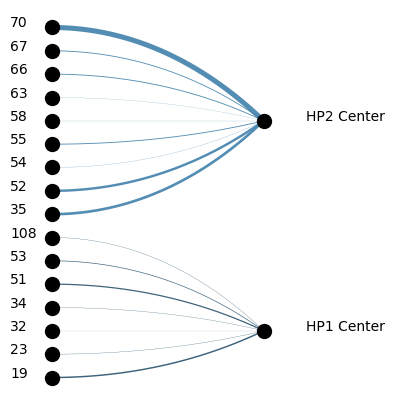

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 5))




counter=0
for i,j,size_thi in zip(node_point_fr[0:7], hp1_changes_mean,
                       sizes_hp1):
    counter=counter+1
    
    point1 = [0,i+0]
    point2 = [1, 2]#hp1
    x,y = hanging_line(point1, point2)

    
    ax.plot(x,y, lw=size_thi, color='#29526D',alpha=0.9)
    
for i,j,size_thi in zip(node_point_fr[7:], hp2_changes_mean,
                       sizes_hp2):
    counter=counter+1
    
    point1 = [0,i+0]
    point2 = [1, 11]#hp2
    x,y = hanging_line(point1, point2)

    
    ax.plot(x,y, lw=size_thi, color='#4181AB',alpha=0.9)
    
# counter=0
# for i,j in zip(node_point_A_unb, node_point_B_unb):
#     counter=counter+1
#     point1 = [0,i+10]
#     point2 = [1,j]
#     x,y = hanging_line(point1, point2)

    
#     ax.plot(x,y, lw=6, color='#5A91FF',alpha=0.9)

# intra connection 7-12 + 0.07 as scaling
# parabola_connect=new_parabola_join(12+0,7+0,0.07)
# ax.plot([-i for i in parabola_connect[1]], 
#          [i for i in parabola_connect[0]], 
#         lw=6, color='#FF7878',alpha=0.9 )

# # intra connection 4-1 + 0.2 as scaling
# parabola_connect=new_parabola_join(4+0,1+0,0.2)
# ax.plot([-i for i in parabola_connect[1]], 
#          [i for i in parabola_connect[0]], 
#         lw=6, color='#FF7878',alpha=0.9 )

counter=0
for i in node_point_fr:
    counter=counter+1
    point1 = [0,i+0]
    
    ax.plot(point1[0], point1[1], 'o', color='black',markersize=10)
    ax.text(point1[0]-0.2,point1[1],"%d"%pock_resi[counter-1]) 
    

counter=0
for j in node_point_to:
    counter=counter+1
    if j!=0:
    
        point2 = [1,j+0]

        ax.plot(point2[0], point2[1], 'o',color='black',markersize=10)
        ax.text(point2[0]+0.2,point2[1],"%s"%spacer_pos[counter-1]) 







ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_yticks([])
ax.set_xticks([])

# plt.savefig('../../plots/pocket_volume/pock_centre_pop_dist_changes_alluvial.png', dpi=450,
#            bbox_inches='tight', transparent=True)

In [20]:
scaled_sizes_hp1

[3.5142913154144733,
 4.046797332498042,
 3.927209446542429,
 4.040074346287984,
 3.582699477956007,
 3.7585125601138696,
 3.8708442651435218]

In [30]:
for i,j in zip(pock_resi, node_point_fr):
    print(i,j)

19 0
23 1
32 2
34 3
51 4
53 5
108 6
35 7
52 8
54 9
55 10
58 11
63 12
66 13
67 14
70 15
